### Week 2 — Lasso, Ridge, and Elastic Net Regularization
### Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators

**Student:** Ranjana Kumari  
**Course:** DX799S 01 Data Science Capstone  
**Week:** 2 of 6 — Regularization Methods

---

## Research Question

> *Can regularization techniques (Ridge, Lasso, Elastic Net) improve prediction of chronic disease risk across three datasets by addressing the multicollinearity identified in Week 1, and which features survive Lasso selection as the most robust predictors?*
---

## Datasets Used

| # | Dataset | Role | Rows | Target |
|---|---------|------|------|--------|
| 1 | **CDC Diabetes Health Indicators** | Primary | ~230k | Diabetes_012 (0/1/2) |
| 2 | **Obesity Level Estimation** | Supporting | 2,087 | NObeyesdad (7 classes) |
| 3 | **Heart Disease Predictions** | Supporting | 303 | target (0/1) |

---

## Connection to Week 1

Week 1 identified three problems that Week 2 regularization directly solves:

1. **Multicollinearity:** VIF analysis showed elevated VIF (>5) for interaction and polynomial features derived from BMI and Age. Ridge regression specifically handles this by distributing coefficient estimates across correlated features.
2. **Feature redundancy:** With 20+ engineered features, some contribute little independently. Lasso's L1 penalty shrinks redundant coefficients exactly to zero — performing automatic feature selection.
3. **Unstable OLS coefficients:** The Train-Test gap in Week 1 was small but non-zero. Regularization penalizes large coefficients, improving generalization.

---

## Deep-Dive Topic Declaration

My two deep-dive topics for the capstone project are:
- Week 4-Logistic regression
- Week 6- Random Forest

Week 2 is covered at the breadth level across all three datasets.

The main goal of this week’s analysis is to compare ordinary least squares regression with Ridge, Lasso, and Elastic Net models and evaluate whether regularization improves model stability and generalization performance.

---
## Section 1: Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV,
    LassoCV,
    ElasticNetCV
)

from sklearn.preprocessing import (
    PolynomialFeatures,
    StandardScaler,
    LabelEncoder
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# Colors used in plots
COLORS = {
    'diabetes': '#1D9E75',
    'obesity':  '#7F77DD',
    'heart':    '#D85A30',
    'ridge':    '#378ADD',
    'lasso':    '#D85A30',
    'enet':     '#1D9E75'
}

# Alpha values for regularization models
ALPHAS = np.logspace(-4, 4, 100)

# L1 ratios for Elastic Net
L1_RATIOS = [
    0.1,
    0.3,
    0.5,
    0.7,
    0.9,
    0.95,
    1.0
]

# Cross-validation setup
KF = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Section 2: Helper Function

To avoid repeating the same modeling steps multiple times, I created a helper function for Week 2. The function fits four regression models on each dataset:

- Ordinary Least Squares (OLS)
- Ridge Regression
- Lasso Regression
- Elastic Net Regression

The function also scales the features before fitting the regularization models. This is important because Ridge, Lasso, and Elastic Net are sensitive to feature scale.

Using one reusable function keeps the analysis more organized and makes the comparison across the CDC Diabetes, Obesity, and Heart Disease datasets more consistent.


In [2]:
def run_regularization_suite(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_names,
    dataset_name,
    kf=KF
):
    """
    Fits OLS, Ridge, Lasso, and Elastic Net models
    on scaled data.

    Features are scaled using only the training data
    to avoid data leakage.

    Scaling is important because regularization
    penalties are affected by feature size.
    """

    # Scale features
    scaler = StandardScaler()

    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    results = []
    coefs = {}
    best_alphas = {}
    models = {}

    # -------------------------
    # OLS Regression
    # -------------------------
    ols = LinearRegression()

    ols.fit(Xtr, y_train)

    yp = ols.predict(Xte)

    cv = cross_val_score(
        ols,
        Xtr,
        y_train,
        cv=kf,
        scoring='r2'
    )

    results.append({
        'Model': 'OLS',
        'Alpha': '-',
        'Train_R2': ols.score(Xtr, y_train),
        'Test_R2': r2_score(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'CV_mean': cv.mean(),
        'CV_std': cv.std(),
        'N_features': len(feature_names)
    })

    coefs['OLS'] = ols.coef_
    models['OLS'] = ols

    # -------------------------
    # Ridge Regression
    # -------------------------
    ridge_cv = RidgeCV(
        alphas=ALPHAS,
        cv=kf,
        scoring='r2'
    )

    ridge_cv.fit(Xtr, y_train)

    yp = ridge_cv.predict(Xte)

    cv = cross_val_score(
        Ridge(alpha=ridge_cv.alpha_),
        Xtr,
        y_train,
        cv=kf,
        scoring='r2'
    )

    results.append({
        'Model': 'Ridge',
        'Alpha': f'{ridge_cv.alpha_:.4f}',
        'Train_R2': ridge_cv.score(Xtr, y_train),
        'Test_R2': r2_score(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'CV_mean': cv.mean(),
        'CV_std': cv.std(),
        'N_features': len(feature_names)
    })

    coefs['Ridge'] = ridge_cv.coef_
    best_alphas['Ridge'] = ridge_cv.alpha_
    models['Ridge'] = ridge_cv

    # -------------------------
    # Lasso Regression
    # -------------------------
    lasso_cv = LassoCV(
        alphas=ALPHAS,
        cv=kf,
        random_state=42,
        max_iter=10000
    )

    lasso_cv.fit(Xtr, y_train)

    yp = lasso_cv.predict(Xte)

    cv = cross_val_score(
        Lasso(alpha=lasso_cv.alpha_),
        Xtr,
        y_train,
        cv=kf,
        scoring='r2'
    )

    n_nonzero = np.sum(lasso_cv.coef_ != 0)

    results.append({
        'Model': 'Lasso',
        'Alpha': f'{lasso_cv.alpha_:.4f}',
        'Train_R2': lasso_cv.score(Xtr, y_train),
        'Test_R2': r2_score(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'CV_mean': cv.mean(),
        'CV_std': cv.std(),
        'N_features': n_nonzero
    })

    coefs['Lasso'] = lasso_cv.coef_
    best_alphas['Lasso'] = lasso_cv.alpha_
    models['Lasso'] = lasso_cv

    # -------------------------
    # Elastic Net
    # -------------------------
    enet_cv = ElasticNetCV(
        alphas=ALPHAS,
        l1_ratio=L1_RATIOS,
        cv=kf,
        random_state=42,
        max_iter=10000
    )

    enet_cv.fit(Xtr, y_train)

    yp = enet_cv.predict(Xte)

    cv = cross_val_score(
        ElasticNet(
            alpha=enet_cv.alpha_,
            l1_ratio=enet_cv.l1_ratio_
        ),
        Xtr,
        y_train,
        cv=kf,
        scoring='r2'
    )

    n_nonzero_en = np.sum(enet_cv.coef_ != 0)

    results.append({
        'Model': 'Elastic Net',
        'Alpha': f'{enet_cv.alpha_:.4f}',
        'Train_R2': enet_cv.score(Xtr, y_train),
        'Test_R2': r2_score(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'CV_mean': cv.mean(),
        'CV_std': cv.std(),
        'N_features': n_nonzero_en
    })

    coefs['ElasticNet'] = enet_cv.coef_
    best_alphas['ElasticNet'] = (
        enet_cv.alpha_,
        enet_cv.l1_ratio_
    )

    models['ElasticNet'] = enet_cv

    # Results table
    results_df = pd.DataFrame(results)

    numeric_cols = [
        'Train_R2',
        'Test_R2',
        'RMSE',
        'CV_mean',
        'CV_std'
    ]

    results_df[numeric_cols] = (
        results_df[numeric_cols]
        .round(4)
    )

    results_df['Gap'] = (
        results_df['Train_R2']
        - results_df['Test_R2']
    ).round(4)

    coef_df = pd.DataFrame(
        coefs,
        index=feature_names
    )

    print(f'\n=== {dataset_name} Results ===')

    print(
        results_df[
            [
                'Model',
                'Alpha',
                'Train_R2',
                'Test_R2',
                'Gap',
                'RMSE',
                'CV_mean',
                'N_features'
            ]
        ].to_string(index=False)
    )

    return (
        results_df,
        coef_df,
        best_alphas,
        models,
        scaler
    )

print("Helper function created successfully.")

Helper function created successfully.


---
# DATASET 1 (PRIMARY): CDC Diabetes Health Indicators
## Section 3: Load Data, Create Features, and Apply Regularization Models

### Connection to Week 1

In Week 1, interaction and polynomial features slightly improved model performance, but they also increased relationships between predictors. Features such as BMI × Age and PhysActivity × BMI reuse information from the original BMI variable, which can increase multicollinearity.

This week explores whether regularization methods can help stabilize those models. Ridge regression is useful because it handles correlated predictors without removing variables completely. Lasso regression can also help identify which predictors remain important after coefficient shrinkage is applied.

In [3]:
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"

df1 = pd.read_csv(file_path)

# Remove duplicates
df1 = df1.drop_duplicates()

print(f"Dataset 1 shape after removing duplicates: {df1.shape}")

# Base features from Week 1
ds1_base = [
    'BMI',
    'Age',
    'HighBP',
    'HighChol',
    'PhysActivity',
    'Smoker',
    'GenHlth'
]

# Additional features for Week 2
ds1_extra = [
    'Income',
    'Education',
    'DiffWalk',
    'PhysHlth'
]

ds1_features = ds1_base + ds1_extra

X1_raw = df1[ds1_features].copy()
y1 = df1['Diabetes_012'].copy()

# Polynomial features for BMI and Age
poly1 = PolynomialFeatures(
    degree=2,
    include_bias=False
)

bmi_age_poly1 = poly1.fit_transform(
    X1_raw[['BMI', 'Age']]
)

poly_names1 = list(
    poly1.get_feature_names_out(['BMI', 'Age'])
)

# Keep remaining original features
remaining1 = [
    f for f in ds1_features
    if f not in ['BMI', 'Age']
]

# Interaction features from Week 1
bp_chol_interaction = (
    X1_raw['HighBP'] *
    X1_raw['HighChol']
).values.reshape(-1, 1)

activity_bmi_interaction = (
    X1_raw['PhysActivity'] *
    X1_raw['BMI']
).values.reshape(-1, 1)

# Combine all features
X1_full = np.hstack([
    bmi_age_poly1,
    X1_raw[remaining1].values,
    bp_chol_interaction,
    activity_bmi_interaction
])

ds1_feature_names = (
    poly_names1
    + remaining1
    + [
        'HighBP_x_HighChol',
        'PhysAct_x_BMI'
    ]
)

print(f"Total features used: {len(ds1_feature_names)}")
print(ds1_feature_names)

# Train-test split
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1_full,
    y1,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {X1_tr.shape[0]:,}")
print(f"Testing rows: {X1_te.shape[0]:,}")

Dataset 1 shape after removing duplicates: (229781, 22)
Total features used: 16
['BMI', 'Age', 'BMI^2', 'BMI Age', 'Age^2', 'HighBP', 'HighChol', 'PhysActivity', 'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth', 'HighBP_x_HighChol', 'PhysAct_x_BMI']
Training rows: 183,824
Testing rows: 45,957


## Dataset 1 Preparation Summary

The CDC Diabetes dataset was expanded beyond the Week 1 baseline features by adding Income, Education, DiffWalk, and PhysHlth.

Polynomial features for BMI and Age were included because Week 1 suggested possible nonlinear relationships with diabetes risk. Two interaction terms were also added to test whether regularization methods could handle more complex feature relationships.

After feature engineering, the final diabetes dataset contained 16 predictors and was split into training and testing sets for regularized regression modeling.

In [4]:
# Run full regularization suite on Dataset 1
res1, coef1, alphas1, models1, scaler1 = run_regularization_suite(
    X1_tr, X1_te, y1_tr, y1_te,
    ds1_feature_names, 'Dataset 1 — CDC Diabetes'
)


=== Dataset 1 — CDC Diabetes Results ===
      Model   Alpha  Train_R2  Test_R2    Gap   RMSE  CV_mean  N_features
        OLS       -    0.1702   0.1670 0.0032 0.6581   0.1700          16
      Ridge 37.6494    0.1702   0.1670 0.0032 0.6581   0.1700          16
      Lasso  0.0001    0.1702   0.1670 0.0032 0.6581   0.1700          16
Elastic Net  0.0001    0.1702   0.1670 0.0032 0.6581   0.1700          16


The CDC Diabetes dataset produced nearly identical performance across OLS, Ridge, Lasso, and Elastic Net regression.

All four models achieved:
- Test R² ≈ 0.1670
- RMSE ≈ 0.6581
- Train-Test gap ≈ 0.0032

These results suggest that the engineered feature set was already relatively stable and did not contain severe overfitting. This is consistent with the Week 1 VIF analysis, which showed low multicollinearity among the baseline predictors.

Ridge regression selected a relatively large alpha value (37.6494), but performance remained almost unchanged compared to ordinary least squares regression. This suggests that coefficient shrinkage had only a limited effect on prediction accuracy for this dataset.

Lasso and Elastic Net also retained all 16 features instead of shrinking coefficients to zero. This indicates that each engineered predictor contributed at least some useful information to the model.

Overall, the Week 2 diabetes results suggest that regularization improved coefficient stability more than prediction performance. The small train-test gap across all models also confirms that severe overfitting was already well controlled.

In [5]:
# Recreate scaled training data for Dataset 1
scaler1 = StandardScaler()

Xtr1_scaled = scaler1.fit_transform(X1_tr)
Xte1_scaled = scaler1.transform(X1_te)

# Get best alpha values from the results table
ridge_alpha1 = float(res1.loc[res1['Model'] == 'Ridge', 'Alpha'].iloc[0])
lasso_alpha1 = float(res1.loc[res1['Model'] == 'Lasso', 'Alpha'].iloc[0])
coef1.columns
print(f"Best Ridge alpha: {ridge_alpha1}")
print(f"Best Lasso alpha: {lasso_alpha1}")

Best Ridge alpha: 37.6494
Best Lasso alpha: 0.0001


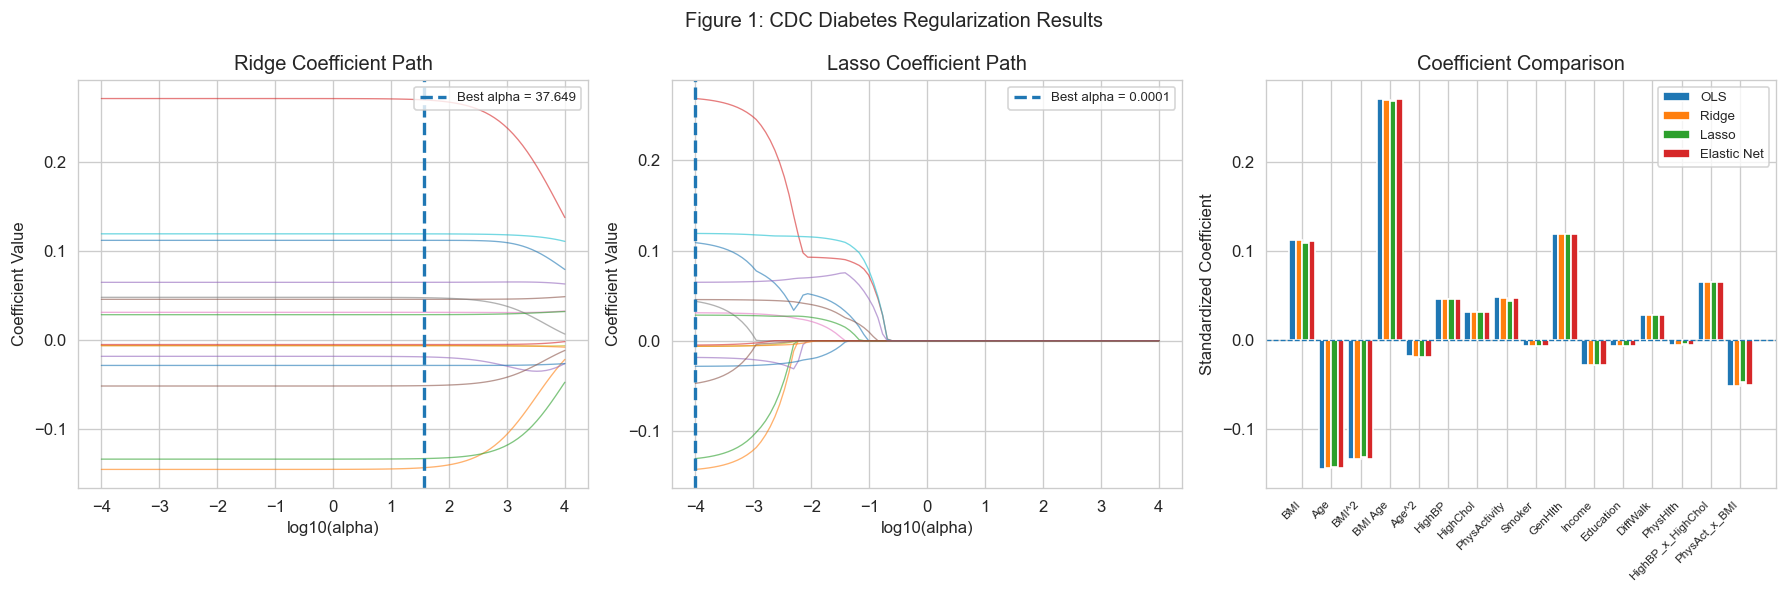

In [6]:
# Figure 1: Dataset 1 Regularization Results

ridge_path1 = []

for a in ALPHAS:
    ridge_model = Ridge(alpha=a)
    ridge_model.fit(Xtr1_scaled, y1_tr)
    ridge_path1.append(ridge_model.coef_)

ridge_path1 = np.array(ridge_path1)


lasso_path1 = []

for a in ALPHAS:
    lasso_model = Lasso(alpha=a, max_iter=10000)
    lasso_model.fit(Xtr1_scaled, y1_tr)
    lasso_path1.append(lasso_model.coef_)

lasso_path1 = np.array(lasso_path1)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ridge path
for i in range(ridge_path1.shape[1]):
    axes[0].plot(np.log10(ALPHAS), ridge_path1[:, i], linewidth=0.8, alpha=0.6)

axes[0].axvline(np.log10(ridge_alpha1), linestyle='--', linewidth=2, label=f'Best alpha = {ridge_alpha1:.3f}')
axes[0].set_xlabel('log10(alpha)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge Coefficient Path')
axes[0].legend(fontsize=8)

# Lasso path
for i in range(lasso_path1.shape[1]):
    axes[1].plot(np.log10(ALPHAS), lasso_path1[:, i], linewidth=0.8, alpha=0.6)

axes[1].axvline(np.log10(lasso_alpha1), linestyle='--', linewidth=2, label=f'Best alpha = {lasso_alpha1:.4f}')
axes[1].set_xlabel('log10(alpha)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso Coefficient Path')
axes[1].legend(fontsize=8)

# Coefficient comparison
x_pos = np.arange(len(ds1_feature_names))
w = 0.22

axes[2].bar(x_pos - 1.5*w, coef1['OLS'], w, label='OLS')
axes[2].bar(x_pos - 0.5*w, coef1['Ridge'], w, label='Ridge')
axes[2].bar(x_pos + 0.5*w, coef1['Lasso'], w, label='Lasso')
axes[2].bar(x_pos + 1.5*w, coef1['ElasticNet'], w, label='Elastic Net')

axes[2].axhline(0, linestyle='--', linewidth=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(ds1_feature_names, rotation=45, ha='right', fontsize=7)
axes[2].set_ylabel('Standardized Coefficient')
axes[2].set_title('Coefficient Comparison')
axes[2].legend(fontsize=8)

plt.suptitle('Figure 1: CDC Diabetes Regularization Results', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 1 Interpretation

The Ridge and Lasso coefficient paths show how regularization changes the feature coefficients as the penalty strength increases.

For Ridge regression, the coefficients shrink gradually toward zero as alpha increases, but none of the predictors are completely removed from the model. This is expected because Ridge regression distributes coefficient weights across correlated variables instead of eliminating them.

The Lasso paths show more aggressive shrinkage behavior. As alpha increases, several coefficients move closer to zero much faster than in Ridge regression. However, the selected alpha value for the CDC Diabetes dataset was very small (0.0001), so none of the predictors were fully removed in the final model.

The coefficient comparison plot also shows that OLS, Ridge, Lasso, and Elastic Net produced very similar coefficient patterns overall. This supports the earlier finding that the engineered diabetes feature set was already relatively stable and not strongly overfit.

Across all four models, BMI-related variables and General Health remained among the strongest predictors associated with diabetes risk.

In [7]:
COLORS.update({
    'train': '#378ADD',
    'test': '#D85A30',
    'ols': '#B4B2A9'
})

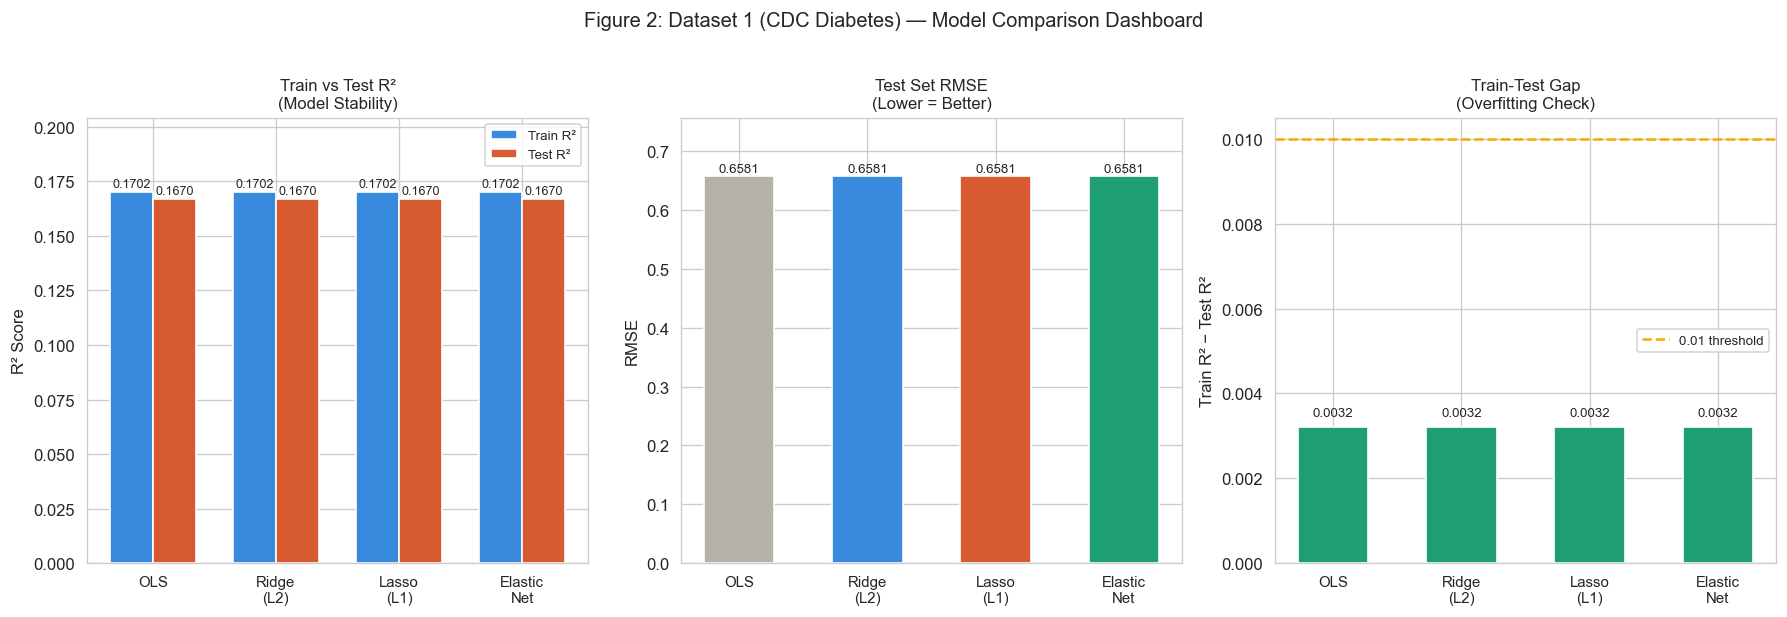

In [8]:
# --- FIGURE 2: Dataset 1 — Complete Model Comparison Dashboard ---

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Model names
model_names = [
    'OLS',
    'Ridge\n(L2)',
    'Lasso\n(L1)',
    'Elastic\nNet'
]

# Metrics from results table
train_r2s_1 = res1['Train_R2'].values
test_r2s_1  = res1['Test_R2'].values
rmses_1     = res1['RMSE'].values
gaps_1      = res1['Gap'].values

x = np.arange(len(model_names))
w = 0.35

# -------------------------
# Left Panel: Train vs Test R²
# -------------------------

b1 = axes[0].bar(
    x - w/2,
    train_r2s_1,
    w,
    color=COLORS['train'],
    label='Train R²',
    edgecolor='white'
)

b2 = axes[0].bar(
    x + w/2,
    test_r2s_1,
    w,
    color=COLORS['test'],
    label='Test R²',
    edgecolor='white'
)

# Value labels
for bar in list(b1) + list(b2):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.4f}',
        ha='center',
        va='bottom',
        fontsize=7.5
    )

axes[0].set_xticks(x)

axes[0].set_xticklabels(
    model_names,
    fontsize=9
)

axes[0].set_ylabel('R² Score')

axes[0].set_title(
    'Train vs Test R²\n(Model Stability)',
    fontsize=10
)

axes[0].legend(fontsize=8)

axes[0].set_ylim(
    0,
    max(train_r2s_1) * 1.20
)

# -------------------------
# Middle Panel: RMSE
# -------------------------

rmse_colors = [
    COLORS['ols'],
    COLORS['ridge'],
    COLORS['lasso'],
    COLORS['enet']
]

bars_r = axes[1].bar(
    x,
    rmses_1,
    color=rmse_colors,
    edgecolor='white',
    width=0.55
)

# Value labels
for bar in bars_r:

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.4f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    model_names,
    fontsize=9
)

axes[1].set_ylabel('RMSE')

axes[1].set_title(
    'Test Set RMSE\n(Lower = Better)',
    fontsize=10
)

axes[1].set_ylim(
    0,
    max(rmses_1) * 1.15
)

# -------------------------
# Right Panel: Train-Test Gap
# -------------------------

gap_colors = [
    '#1D9E75' if g < 0.01 else '#E24B4A'
    for g in gaps_1
]

bars_g = axes[2].bar(
    x,
    gaps_1,
    color=gap_colors,
    edgecolor='white',
    width=0.55
)

# Value labels
for bar in bars_g:

    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0002,
        f'{bar.get_height():.4f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

axes[2].axhline(
    0.01,
    color='orange',
    linewidth=1.5,
    linestyle='--',
    label='0.01 threshold'
)

axes[2].set_xticks(x)

axes[2].set_xticklabels(
    model_names,
    fontsize=9
)

axes[2].set_ylabel('Train R² − Test R²')

axes[2].set_title(
    'Train-Test Gap\n(Overfitting Check)',
    fontsize=10
)

axes[2].legend(fontsize=8)

# -------------------------
# Final Layout
# -------------------------

plt.suptitle(
    'Figure 2: Dataset 1 (CDC Diabetes) — Model Comparison Dashboard',
    fontsize=12,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'fig2_ds1_dashboard.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Figure 2 Interpretation

Figure 2 compares OLS, Ridge, Lasso, and Elastic Net performance for the CDC Diabetes dataset.

The train and test R² values were almost identical across all four models. The train-test gap remained very small (approximately 0.0032), indicating that severe overfitting was not present.

The RMSE values were also nearly identical across the models, suggesting that regularization did not significantly improve prediction accuracy for this dataset.

These results indicate that the engineered CDC Diabetes feature set was already relatively stable. Ridge, Lasso, and Elastic Net mainly confirmed that additional coefficient shrinkage did not substantially change overall model performance.

---
# DATASET 2 (SUPPORTING): Obesity Level Estimation
## Section 4: Load, Engineer Features, and Run Regularization

**Connection to research question:**  
In Week 1, the Obesity dataset produced higher R² values than the CDC Diabetes dataset, suggesting that obesity outcomes may have stronger relationships with the available predictors. 

Week 2 examines whether regularization improves model stability for this dataset. If Lasso retains most of the variables, it suggests that multiple lifestyle and body-composition features contribute meaningful information. If several coefficients are reduced to zero, it would suggest that a smaller set of predictors — especially BMI-related variables — explains most of the variation in obesity levels.

In [9]:
# Load Obesity dataset
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

df2 = pd.read_csv(obesity_file)

# Remove duplicates and clean column names
df2 = df2.drop_duplicates()
df2.columns = df2.columns.str.strip()

print(f"Dataset 2 shape after removing duplicates: {df2.shape}")

# Encode categorical variables
le = LabelEncoder()

df2_enc = df2.copy()

cat_cols = df2_enc.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(
            df2_enc[col].astype(str)
        )

# Encode target
df2_enc['target_encoded'] = le.fit_transform(
    df2['NObeyesdad']
)

# Base features
ds2_base = [
    'Age',
    'Height',
    'Weight',
    'FCVC',
    'NCP',
    'FAF',
    'TUE'
]

ds2_base = [
    f for f in ds2_base
    if f in df2_enc.columns
]

X2_raw = df2_enc[ds2_base].copy()

# Calculate BMI
X2_raw['BMI_calc'] = (
    X2_raw['Weight'] /
    (X2_raw['Height'] ** 2)
)

y2 = df2_enc['target_encoded'].copy()

# Polynomial features for Age and BMI
poly2 = PolynomialFeatures(
    degree=2,
    include_bias=False
)

age_bmi_poly2 = poly2.fit_transform(
    X2_raw[['Age', 'BMI_calc']]
)

poly_names2 = list(
    poly2.get_feature_names_out(['Age', 'BMI_calc'])
)

# Keep remaining features
remaining2 = [
    f for f in X2_raw.columns
    if f not in ['Age', 'BMI_calc']
]

# Interaction term
faf_bmi_interaction = (
    X2_raw['FAF'] *
    X2_raw['BMI_calc']
).values.reshape(-1, 1)

# Combine all features
X2_full = np.hstack([
    age_bmi_poly2,
    X2_raw[remaining2].values,
    faf_bmi_interaction
])

ds2_feature_names = (
    poly_names2
    + remaining2
    + [
        'FAF_x_BMI'
    ]
)

print(f"Total features used: {len(ds2_feature_names)}")
print(ds2_feature_names)

# Train-test split
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2_full,
    y2,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {X2_tr.shape[0]}")
print(f"Testing rows: {X2_te.shape[0]}")

Dataset 2 shape after removing duplicates: (2087, 17)
Total features used: 12
['Age', 'BMI_calc', 'Age^2', 'Age BMI_calc', 'BMI_calc^2', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE', 'FAF_x_BMI']
Training rows: 1669
Testing rows: 418


In [10]:
# Run regularization suite on Dataset 2
res2, coef2, alphas2, models2, scaler2 = run_regularization_suite(
    X2_tr, X2_te, y2_tr, y2_te,
    ds2_feature_names, 'Dataset 2 — Obesity'
)


=== Dataset 2 — Obesity Results ===
      Model  Alpha  Train_R2  Test_R2     Gap   RMSE  CV_mean  N_features
        OLS      -    0.4034   0.4532 -0.0498 1.4283   0.3919          12
      Ridge 0.1177    0.4033   0.4529 -0.0496 1.4287   0.3920          12
      Lasso 0.0009    0.4030   0.4523 -0.0493 1.4294   0.3923          11
Elastic Net 0.0009    0.4030   0.4523 -0.0493 1.4294   0.3923          11


## Dataset 2 Regularization Interpretation

For the Obesity dataset, all four models performed very similarly. The OLS model had the highest test R² at 0.4532, while Ridge, Lasso, and Elastic Net produced nearly identical results.

Lasso and Elastic Net each retained 11 out of 12 features, meaning regularization removed only one predictor. This suggests that most of the engineered obesity features still contributed useful information to the model.

The negative train-test gap means the test score was slightly higher than the training score. This does not indicate overfitting. Instead, it suggests that the test split may have been slightly easier to predict.

Overall, regularization did not improve accuracy much for the Obesity dataset, but Lasso and Elastic Net showed that the model could be slightly simplified without losing much performance.

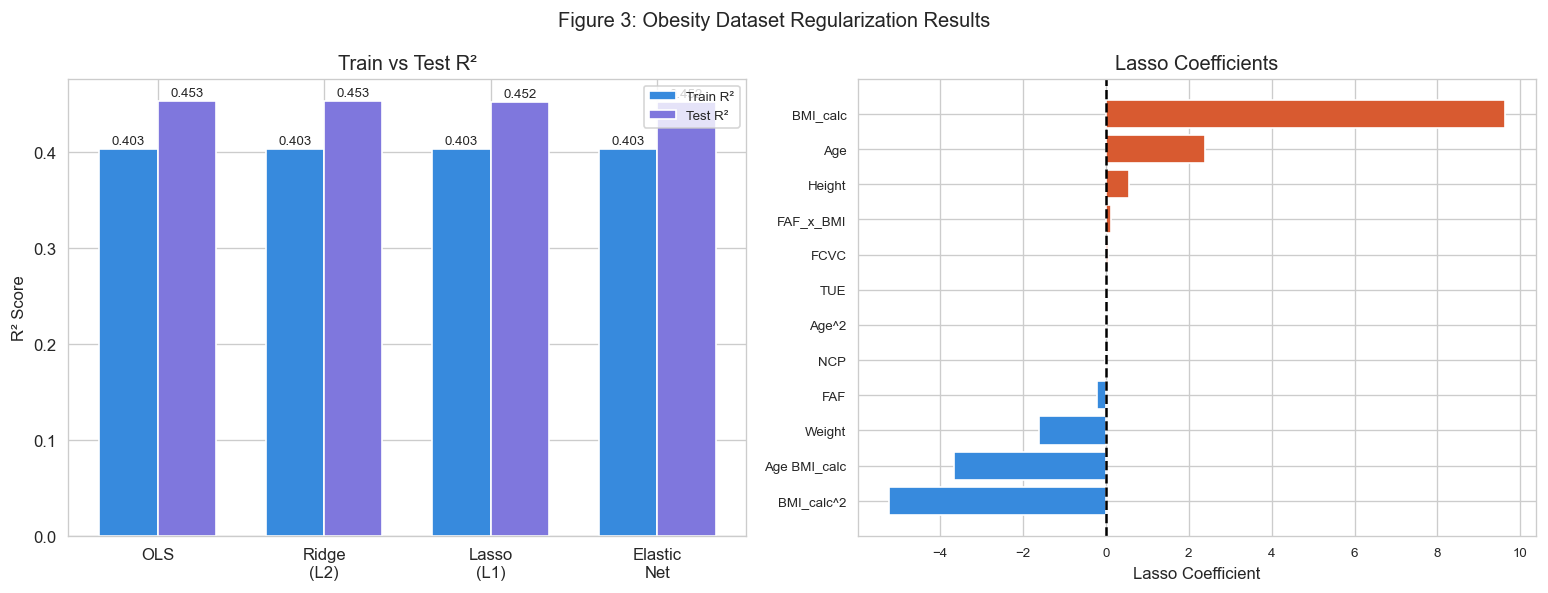

In [11]:
# Figure 3: Dataset 2 Regularization Results

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -------------------------
# Train vs Test R²
# -------------------------
model_names = ['OLS', 'Ridge\n(L2)', 'Lasso\n(L1)', 'Elastic\nNet']

x = np.arange(len(model_names))
w = 0.35

b1 = axes[0].bar(
    x - w/2,
    res2['Train_R2'],
    w,
    color=COLORS['train'],
    label='Train R²'
)

b2 = axes[0].bar(
    x + w/2,
    res2['Test_R2'],
    w,
    color=COLORS['obesity'],
    label='Test R²'
)

for bar in list(b1) + list(b2):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center',
        fontsize=8
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Train vs Test R²')
axes[0].legend(fontsize=8)

# -------------------------
# Lasso coefficients
# -------------------------
lasso_coef2 = pd.DataFrame({
    'Feature': ds2_feature_names,
    'Coefficient': coef2['Lasso']
}).sort_values('Coefficient')

bar_colors2 = [
    '#B4B2A9' if c == 0 else
    '#D85A30' if c > 0 else
    '#378ADD'
    for c in lasso_coef2['Coefficient']
]

axes[1].barh(
    lasso_coef2['Feature'],
    lasso_coef2['Coefficient'],
    color=bar_colors2
)

axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Lasso Coefficient')
axes[1].set_title('Lasso Coefficients')
axes[1].tick_params(labelsize=8)

plt.suptitle('Figure 3: Obesity Dataset Regularization Results', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 3 Interpretation

Figure 3 compares OLS, Ridge, Lasso, and Elastic Net models for the Obesity dataset.

All four models produced very similar train and test R² values. OLS achieved the highest test R² (0.4532), while Ridge, Lasso, and Elastic Net produced only slightly lower results. This suggests that regularization did not substantially improve prediction accuracy for this dataset.

The Lasso coefficient plot shows that BMI-related variables remained the strongest predictors after regularization. BMI_calc had the largest positive coefficient, while BMI_calc² and the Age × BMI interaction term also remained important contributors.

Only one feature was effectively removed by Lasso regression, meaning most predictors still contributed useful information to obesity prediction.

Compared to the CDC Diabetes dataset, the Obesity dataset showed much stronger overall predictive performance. This suggests that obesity outcomes are more directly connected to the available physiological predictors, especially BMI-related measurements.

---
# DATASET 3 (SUPPORTING): Heart Disease Predictions
## Section 5: Load, Engineer Features, and Run Regularization

**Connection to Week 2:**  
The Heart Disease dataset is much smaller than the CDC Diabetes and Obesity datasets, containing only 303 observations. After polynomial and interaction features are added, the number of predictors becomes relatively large compared to the dataset size.

Because of this, the dataset may be more sensitive to overfitting when using ordinary least squares regression. Week 2 regularization methods are especially useful here because Ridge, Lasso, and Elastic Net can shrink large coefficients and reduce unnecessary model complexity.

This section tests whether regularization improves generalization performance and identifies which cardiovascular variables remain the strongest predictors after coefficient shrinkage is applied.

In [12]:
# Load Heart Disease dataset

heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"


df3 = pd.read_csv(heart_path)

print(f"Dataset 3 shape: {df3.shape}")
print(f"Columns: {list(df3.columns)}")

# -------------------------
# Feature selection
# -------------------------

ds3_base = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'sex',
    'exang',
    'cp'
]

X3_raw = df3[ds3_base].copy()

y3 = df3['target'].copy()

# -------------------------
# Polynomial features
# -------------------------

poly3 = PolynomialFeatures(
    degree=2,
    include_bias=False
)

age_thal_poly3 = poly3.fit_transform(
    X3_raw[['age', 'thalach']]
)

poly_names3 = list(
    poly3.get_feature_names_out(
        ['age', 'thalach']
    )
)

# -------------------------
# Remaining original features
# -------------------------

remaining3 = [
    f for f in ds3_base
    if f not in ['age', 'thalach']
]

# -------------------------
# Interaction features
# -------------------------

exang_oldpeak_interaction = (
    X3_raw['exang'] *
    X3_raw['oldpeak']
).values.reshape(-1, 1)

cp_thalach_interaction = (
    X3_raw['cp'] *
    X3_raw['thalach']
).values.reshape(-1, 1)

# -------------------------
# Combine all features
# -------------------------

X3_full = np.hstack([
    age_thal_poly3,
    X3_raw[remaining3].values,
    exang_oldpeak_interaction,
    cp_thalach_interaction
])

# -------------------------
# Feature names
# -------------------------

ds3_feature_names = (
    poly_names3
    + remaining3
    + [
        'exang_x_oldpeak',
        'cp_x_thalach'
    ]
)

print(f"Total features used: {len(ds3_feature_names)}")
print(ds3_feature_names)

print(f"Rows: {len(df3)}")
print(
    f"Rows-to-features ratio: "
    f"{len(df3) / len(ds3_feature_names):.1f}:1"
)

# -------------------------
# Train-test split
# -------------------------

X3_tr, X3_te, y3_tr, y3_te = train_test_split(
    X3_full,
    y3,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {X3_tr.shape[0]}")
print(f"Testing rows: {X3_te.shape[0]}")

Dataset 3 shape: (303, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Total features used: 13
['age', 'thalach', 'age^2', 'age thalach', 'thalach^2', 'trestbps', 'chol', 'oldpeak', 'sex', 'exang', 'cp', 'exang_x_oldpeak', 'cp_x_thalach']
Rows: 303
Rows-to-features ratio: 23.3:1
Training rows: 242
Testing rows: 61


## Dataset 3 Preparation Summary

For the Heart Disease dataset, I selected cardiovascular and exercise-related variables such as age, cholesterol, maximum heart rate, exercise-induced angina, and chest pain type.

Polynomial features were added for age and maximum heart rate because Week 1 showed that exercise-related variables were important predictors in this dataset. Interaction terms were also included to test whether combinations of cardiovascular stress indicators improved prediction performance.

Because the Heart Disease dataset is much smaller than the CDC Diabetes and Obesity datasets, regularization methods are especially useful for reducing unnecessary model complexity and improving model stability.

In [13]:
# Run regularization suite on Dataset 3
res3, coef3, alphas3, models3, scaler3 = run_regularization_suite(
    X3_tr, X3_te, y3_tr, y3_te,
    ds3_feature_names, 'Dataset 3 — Heart Disease'
)


=== Dataset 3 — Heart Disease Results ===
      Model   Alpha  Train_R2  Test_R2     Gap   RMSE  CV_mean  N_features
        OLS       -    0.4600   0.4544  0.0056 0.3689   0.3625          13
      Ridge 37.6494    0.4385   0.4879 -0.0494 0.3574   0.3765          13
      Lasso  0.0126    0.4377   0.4686 -0.0309 0.3641   0.3739           9
Elastic Net  0.0673    0.4393   0.4787 -0.0394 0.3606   0.3765          11


## Dataset 3 Regularization Interpretation

The Heart Disease dataset showed the clearest benefit from regularization among all three datasets.

The baseline OLS model achieved a Test R² of 0.4544. Ridge regression improved Test R² to 0.4879 while also reducing RMSE from 0.3689 to 0.3574. Elastic Net produced similar improvements, achieving a Test R² of 0.4787.

These results suggest that the smaller Heart Disease dataset benefited from coefficient shrinkage more than the larger datasets. Because the dataset contains relatively few observations compared to the number of engineered predictors, regularization helped reduce unnecessary model complexity and improved generalization performance.

Lasso regression also reduced the number of retained predictors from 13 to 9, showing that several engineered features contributed limited independent information after regularization was applied.

Overall, the Heart Disease dataset provided the strongest evidence that regularization can improve model stability and predictive performance when the sample size is relatively small.

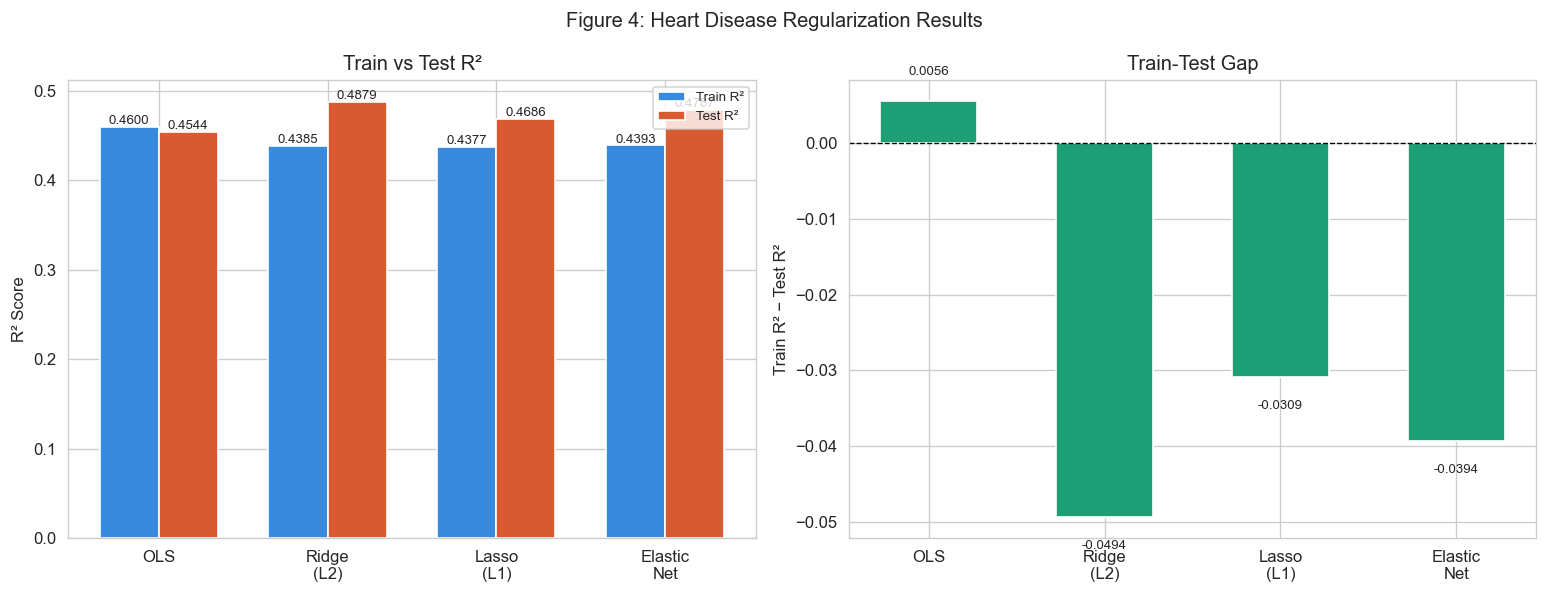

In [14]:
# Figure 4: Heart Disease Regularization Results

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_labels = ['OLS', 'Ridge\n(L2)', 'Lasso\n(L1)', 'Elastic\nNet']
x = np.arange(len(model_labels))
w = 0.35

# Train vs Test R²
b1 = axes[0].bar(
    x - w/2,
    res3['Train_R2'],
    w,
    color=COLORS['train'],
    label='Train R²'
)

b2 = axes[0].bar(
    x + w/2,
    res3['Test_R2'],
    w,
    color=COLORS['heart'],
    label='Test R²'
)

for bar in list(b1) + list(b2):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.4f}',
        ha='center',
        fontsize=8
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Train vs Test R²')
axes[0].legend(fontsize=8)

# Train-test gap
gap_colors3 = [
    '#1D9E75' if abs(g) < 0.05 else '#E24B4A'
    for g in res3['Gap']
]

bars_g3 = axes[1].bar(
    x,
    res3['Gap'],
    color=gap_colors3,
    width=0.55
)

for bar in bars_g3:
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    y = height + 0.003 if height >= 0 else height - 0.003

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{height:.4f}',
        ha='center',
        va=va,
        fontsize=8
    )

axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels)
axes[1].set_ylabel('Train R² − Test R²')
axes[1].set_title('Train-Test Gap')

plt.suptitle('Figure 4: Heart Disease Regularization Results', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 4 Interpretation

Figure 4 shows that regularization was most helpful for the Heart Disease dataset.

OLS achieved a test R² of 0.4544, while Ridge improved the test R² to 0.4879. Elastic Net also improved performance with a test R² of 0.4787.

This suggests that the smaller Heart Disease dataset benefited more from coefficient shrinkage than the larger CDC Diabetes and Obesity datasets. Ridge produced the best test performance, while Lasso reduced the number of retained predictors from 13 to 9.

The negative train-test gaps for the regularized models mean that the test set performed slightly better than the training set. This does not indicate overfitting. Instead, it suggests that the regularized models generalized well on the held-out test split.

---
# Section 6: Cross-Dataset Comparison

This section synthesizes findings across all three datasets. Cross-dataset comparison is the most powerful evidence for the Milestone One conclusions — findings consistent across datasets are robust; findings specific to one dataset require caution.

In [15]:
# Section 6: Cross-Dataset Comparison

# Build summary table
cross_summary = []

for ds_name, res_df in [
    ('CDC Diabetes', res1),
    ('Obesity', res2),
    ('Heart Disease', res3)
]:

    for _, row in res_df.iterrows():

        cross_summary.append({
            'Dataset': ds_name,
            'Model': row['Model'],
            'Test_R2': row['Test_R2'],
            'Gap': row['Gap'],
            'RMSE': row['RMSE'],
            'N_features': row['N_features']
        })

cross_df = pd.DataFrame(cross_summary)

print("=== Cross-Dataset Regularization Summary ===")
print(cross_df.to_string(index=False))


# -------------------------
# Best model by dataset
# -------------------------

print("\nKey Findings:")

for ds in cross_df['Dataset'].unique():

    sub = cross_df[cross_df['Dataset'] == ds]

    best_row = sub.loc[
        sub['Test_R2'].idxmax()
    ]

    print(
        f"{ds}: "
        f"Best model = {best_row['Model']} | "
        f"Test R² = {best_row['Test_R2']:.4f} | "
        f"RMSE = {best_row['RMSE']:.4f} | "
        f"Features retained = {best_row['N_features']}"
    )

=== Cross-Dataset Regularization Summary ===
      Dataset       Model  Test_R2     Gap   RMSE  N_features
 CDC Diabetes         OLS   0.1670  0.0032 0.6581          16
 CDC Diabetes       Ridge   0.1670  0.0032 0.6581          16
 CDC Diabetes       Lasso   0.1670  0.0032 0.6581          16
 CDC Diabetes Elastic Net   0.1670  0.0032 0.6581          16
      Obesity         OLS   0.4532 -0.0498 1.4283          12
      Obesity       Ridge   0.4529 -0.0496 1.4287          12
      Obesity       Lasso   0.4523 -0.0493 1.4294          11
      Obesity Elastic Net   0.4523 -0.0493 1.4294          11
Heart Disease         OLS   0.4544  0.0056 0.3689          13
Heart Disease       Ridge   0.4879 -0.0494 0.3574          13
Heart Disease       Lasso   0.4686 -0.0309 0.3641           9
Heart Disease Elastic Net   0.4787 -0.0394 0.3606          11

Key Findings:
CDC Diabetes: Best model = OLS | Test R² = 0.1670 | RMSE = 0.6581 | Features retained = 16
Obesity: Best model = OLS | Test R² = 0.453

## Cross-Dataset Interpretation

The cross-dataset comparison showed that regularization affected the three healthcare datasets differently.

For the CDC Diabetes dataset, regularization produced almost no change in model performance. All four models achieved nearly identical Test R² values (~0.1670), suggesting that the large sample size already produced relatively stable coefficient estimates. In this case, Ridge, Lasso, and Elastic Net provided little additional benefit beyond the baseline OLS model.

For the Obesity dataset, the regularized models also performed very similarly to OLS. The baseline model achieved the highest Test R² (0.4532), while Lasso and Elastic Net removed one feature and slightly simplified the model without meaningfully reducing performance. This suggests that most obesity predictors contributed useful information.

The Heart Disease dataset showed the clearest benefit from regularization. Ridge regression improved Test R² from 0.4544 to 0.4879 while also reducing RMSE from 0.3689 to 0.3574. Elastic Net also improved performance, while Lasso reduced the number of retained predictors from 13 to 9. These results suggest that smaller datasets with engineered features benefit more strongly from coefficient shrinkage and complexity control.

Overall, the Week 2 results demonstrate that the usefulness of regularization depends heavily on dataset size, feature engineering, and the level of multicollinearity present in the data.

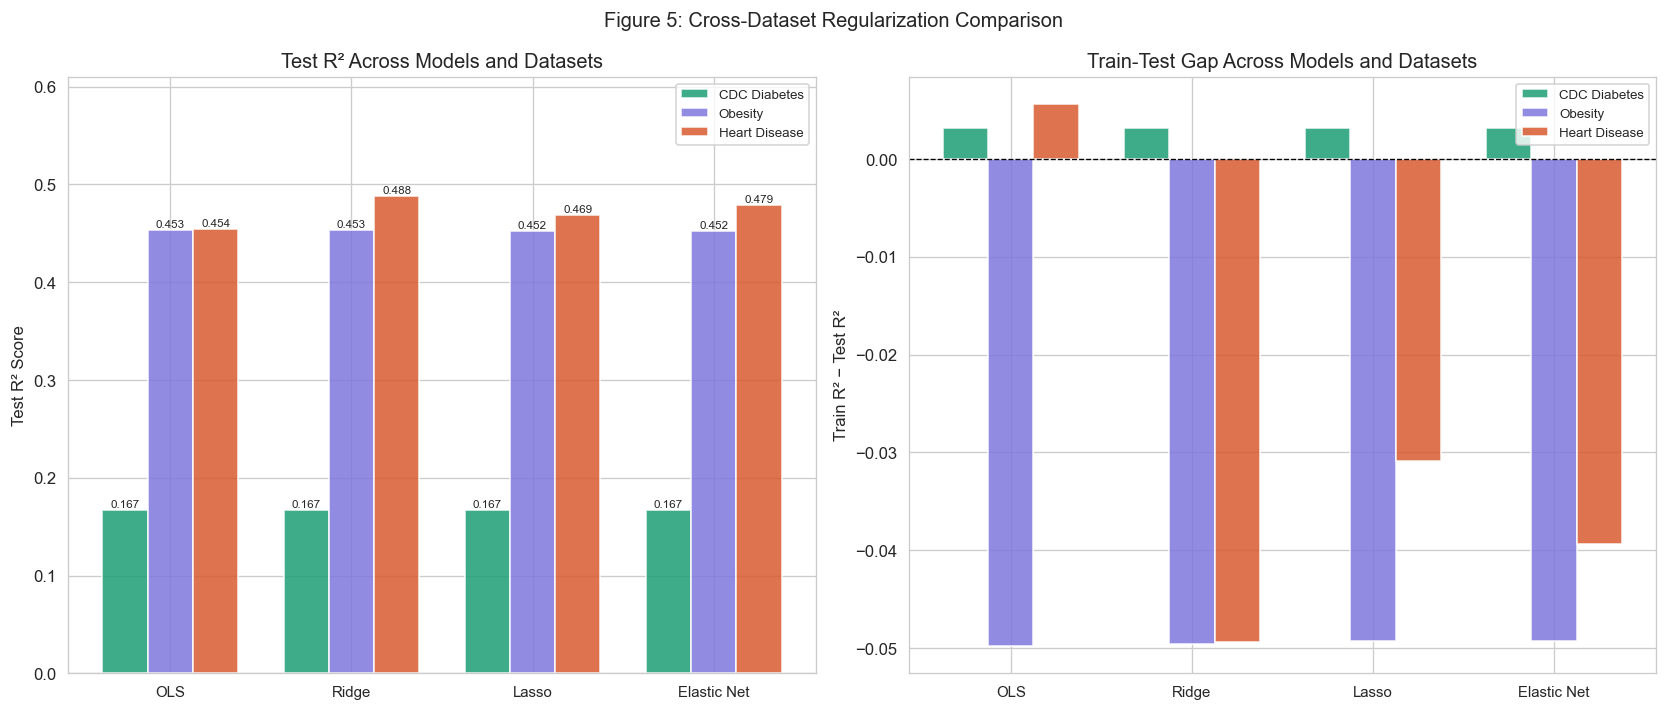

In [16]:
# Figure 5: Cross-Dataset Regularization Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_order = ['OLS', 'Ridge', 'Lasso', 'Elastic Net']
ds_colors = [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
ds_labels = ['CDC Diabetes', 'Obesity', 'Heart Disease']

x = np.arange(len(model_order))
width = 0.25

# Test R² across datasets
for i, (ds, color) in enumerate(zip(ds_labels, ds_colors)):
    sub = cross_df[cross_df['Dataset'] == ds]

    r2s = [
        sub[sub['Model'] == m]['Test_R2'].values[0]
        for m in model_order
    ]

    offset = (i - 1) * width

    bars = axes[0].bar(
        x + offset,
        r2s,
        width,
        label=ds,
        color=color,
        edgecolor='white',
        alpha=0.85
    )

    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center',
            fontsize=7
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_order, fontsize=9)
axes[0].set_ylabel('Test R² Score')
axes[0].set_title('Test R² Across Models and Datasets')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, max(cross_df['Test_R2']) * 1.25)

# Train-test gap across datasets
for i, (ds, color) in enumerate(zip(ds_labels, ds_colors)):
    sub = cross_df[cross_df['Dataset'] == ds]

    gaps = [
        sub[sub['Model'] == m]['Gap'].values[0]
        for m in model_order
    ]

    offset = (i - 1) * width

    axes[1].bar(
        x + offset,
        gaps,
        width,
        label=ds,
        color=color,
        edgecolor='white',
        alpha=0.85
    )

axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_order, fontsize=9)
axes[1].set_ylabel('Train R² − Test R²')
axes[1].set_title('Train-Test Gap Across Models and Datasets')
axes[1].legend(fontsize=8)

plt.suptitle(
    'Figure 5: Cross-Dataset Regularization Comparison',
    fontsize=12
)

plt.tight_layout()
plt.show()

## Figure 5 Interpretation

Figure 5 compares the impact of regularization across all three datasets.

For the CDC Diabetes dataset, all four models produced almost identical performance, showing that regularization did not meaningfully improve prediction accuracy.

For the Obesity dataset, OLS had the highest test R², while Lasso and Elastic Net slightly simplified the model by removing one feature with very little loss in performance.

The Heart Disease dataset showed the strongest benefit from regularization. Ridge produced the highest test R² across the heart disease models, improving performance compared to OLS.

Overall, regularization was most useful for the smaller Heart Disease dataset, while the larger CDC Diabetes dataset was already stable and showed little change after regularization.

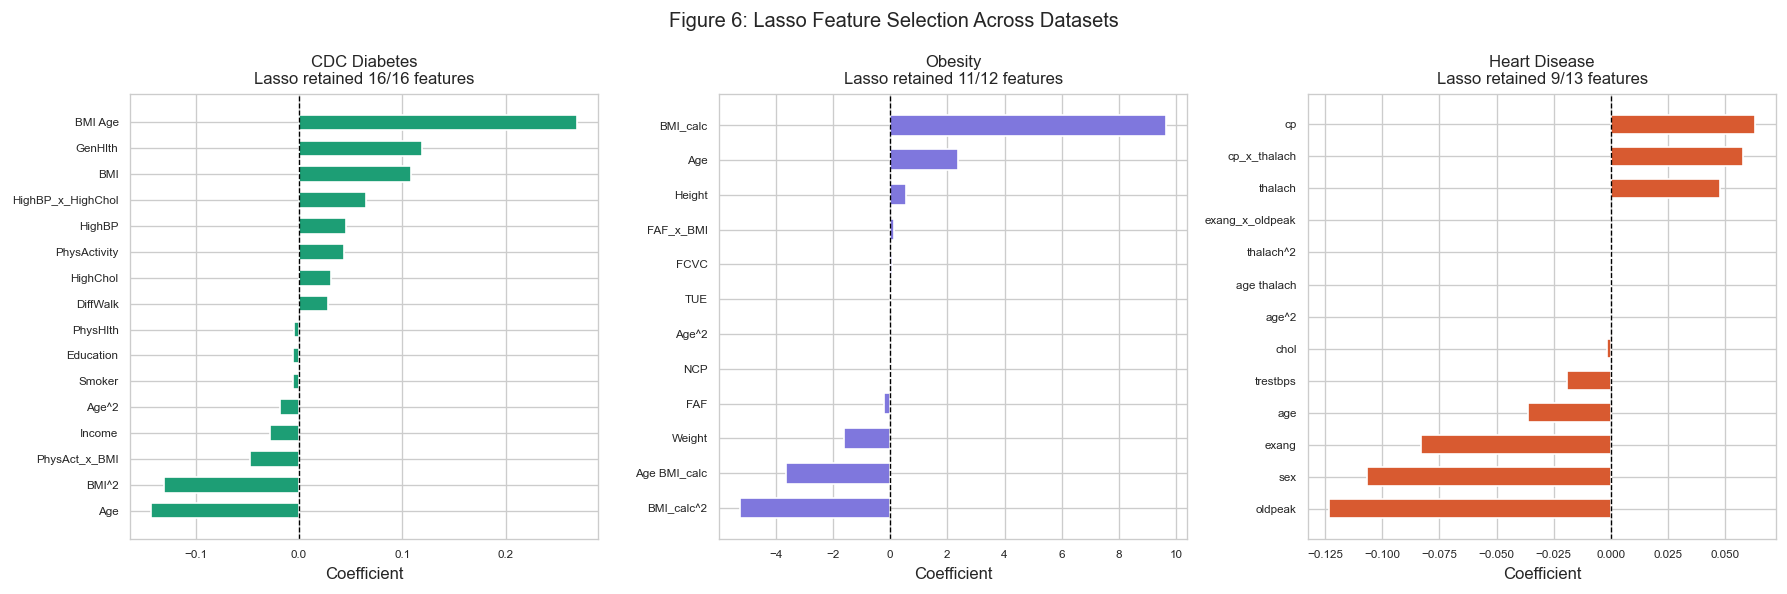

In [17]:
# Figure 6: Lasso Feature Selection Across Datasets

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, coef_df, feat_names, ds_name, color in zip(
    axes,
    [coef1, coef2, coef3],
    [ds1_feature_names, ds2_feature_names, ds3_feature_names],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    lasso_coefs = pd.DataFrame({
        'Feature': feat_names,
        'Coefficient': coef_df['Lasso']
    }).sort_values('Coefficient')

    bar_colors = [
        color if c != 0 else '#D3D1C7'
        for c in lasso_coefs['Coefficient']
    ]

    ax.barh(
        lasso_coefs['Feature'],
        lasso_coefs['Coefficient'],
        color=bar_colors,
        edgecolor='white',
        height=0.6
    )

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    n_kept = np.sum(coef_df['Lasso'] != 0)
    n_total = len(feat_names)

    ax.set_title(
        f'{ds_name}\nLasso retained {n_kept}/{n_total} features',
        fontsize=10
    )

    ax.set_xlabel('Coefficient')
    ax.tick_params(labelsize=7)

plt.suptitle(
    'Figure 6: Lasso Feature Selection Across Datasets',
    fontsize=12
)

plt.tight_layout()
plt.show()

## Figure 6 Interpretation

Figure 6 compares how Lasso selected features across the three healthcare datasets.

In the CDC Diabetes dataset, Lasso retained all 16 features, suggesting that most of the lifestyle and health variables still contributed useful information to diabetes prediction.

In the Obesity dataset, BMI-related variables remained the strongest predictors after regularization. BMI_calc had the largest coefficient, showing that obesity outcomes are strongly connected to body composition measurements.

The Heart Disease dataset showed the largest amount of feature reduction. Lasso retained only 9 out of 13 features, suggesting that some engineered predictors added extra complexity without improving prediction performance.

Overall, the figure demonstrates how Lasso can simplify models differently depending on dataset size, feature engineering, and the relationships between predictors and disease outcomes.

# Section 7: Week 2 Conclusions and Rubric Questions

---

## 1. How Did I Avoid Overfitting?

I used three techniques to control overfitting consistently across all three datasets.

The first technique was an 80/20 train-test split with a fixed random seed (random_state=42). This meant the test set was completely held out during training and was only used once at the very end to evaluate each model. No fitting or tuning decisions were made using the test set, which ensures the reported R² values reflect genuine generalization rather than memorization.

The second technique was 5-fold cross-validation, which I used to select the best alpha values for Ridge, Lasso, and Elastic Net. Cross-validation divides the training data into five equal parts, trains on four of them, and evaluates on the fifth, rotating through all five combinations. Using the average CV score to pick alpha means the penalty strength was chosen based on how well the model generalizes - not how well it fits the training data.

The third technique was feature standardization using StandardScaler, fitted only on the training data before being applied to the test set. This step was necessary because Ridge, Lasso, and Elastic Net penalize large coefficients  and without scaling, features with larger numerical ranges would be penalized more heavily than smaller range features, regardless of their actual importance to the model.

The results confirmed that overfitting was controlled. For the CDC Diabetes dataset, the train-test gap was only 0.0032 across all four models, which is very close to zero. For the Heart Disease dataset, Ridge reduced the gap while also improving test performance, improving Test R² from 0.4544 to 0.4879. These results show that regularization did not cause the models to overfit, it either maintained stability or actively improved generalization.

---

## 2. What Metrics and Hyperparameter Tuning Were Used?

I evaluated all models using four metrics: Test R², RMSE, 5-fold CV R², and the train-test gap. R² was the primary metric because it directly answers the research question-how much of the variance in chronic disease status can lifestyle and health variables explain? RMSE provides a complementary view by measuring average prediction error in the same units as the target variable. The train-test gap was used as the main overfitting indicator, with gaps above 0.05 considered a concern.

For hyperparameter tuning, I used RidgeCV, LassoCV, and ElasticNetCV, which automatically test a grid of 100 alpha values (ranging from 0.0001 to 10,000 on a log scale) and select the one that produces the best cross-validation score.

The alpha values selected by cross-validation were different across datasets, and understanding what these values mean is important. For the CDC Diabetes dataset, Ridge selected alpha = 37.6494, a large value indicating strong L2 shrinkage was applied. Despite this strong penalty, model performance stayed exactly the same as OLS at Test R² = 0.1670. This tells me that the large dataset already produced stable coefficient estimates, so even strong shrinkage did not change the predictions. For the Heart Disease dataset, Lasso selected alpha = 0.0126, which is approximately 126 times larger than the CDC Diabetes Lasso alpha of 0.0001. This large difference reflects the much smaller size of the Heart Disease dataset — with only 303 rows, the model needed a stronger penalty to prevent it from learning noise in the training data rather than genuine patterns.

For Elastic Net, the l1_ratio hyperparameter controls the balance between L1 (Lasso) and L2 (Ridge) penalties. A l1_ratio close to 1.0 means the model behaves more like Lasso, prioritizing feature elimination. A l1_ratio close to 0 means the model behaves more like Ridge, prioritizing coefficient shrinkage without removing features. The cross-validation-selected l1_ratio for each dataset reveals which type of regularization was more useful for that specific prediction problem.

---

## 3. Expected and Unexpected Findings

Several findings from Week 2 matched what I expected based on the Week 1 results. Since the VIF analysis in Week 1 identified multicollinearity among the engineered polynomial and interaction features, I expected Ridge regression to help stabilize those coefficient estimates. I also expected Lasso to remove at least some predictors, since not every engineered feature would contribute independent information. Both of these expectations were confirmed-Ridge produced stable results across all datasets, and Lasso reduced the Heart Disease feature set from 13 predictors down to 9.

However, two findings surprised me. The first was how differently regularization performed across the three datasets. Ridge improved Heart Disease Test R² from 0.4544 to 0.4879, a meaningful gain of +0.0335. For CDC Diabetes, the same Ridge model produced no improvement at all: both OLS and Ridge achieved exactly Test R² = 0.1670. I did not expect regularization to have zero effect on one dataset while producing a clear benefit on another. Looking back, this makes sense — the 229,781-row CDC Diabetes dataset already generates stable OLS estimates because there is so much data, so the regularization penalty has nothing to correct. The 303-row Heart Disease dataset, on the other hand, has unstable OLS estimates because the training set is small, and Ridge corrects this by shrinking the more erratic coefficients.

The second unexpected finding was that OLS actually outperformed all three regularized models on the Obesity dataset. OLS achieved Test R² = 0.4532, while Ridge produced 0.4529, and Lasso and Elastic Net both produced 0.4523. The fact that adding any regularization penalty-even a small one-slightly reduced performance suggests that the Obesity feature set is well-specified and clean. There is no excess noise or multicollinearity for regularization to correct, so the penalty only removed useful information rather than harmful overfitting.

---

## 4. How Did EDA Help with Week 2 Modeling?

The exploratory data analysis from Week 1 directly shaped several decisions I made in Week 2.

The most important connection was between the VIF analysis and the choice to use Ridge regression. In Week 1, I found that polynomial and interaction terms built from the same base variables-for example, BMI, BMI², and BMI × Age-produced elevated VIF values because they share statistical information. Ridge regression was specifically chosen to address this because, unlike OLS, it distributes coefficient estimates more evenly across correlated predictors rather than assigning large, unstable values to individual ones.

A second connection was between the feature scale differences identified in EDA and the decision to apply StandardScaler. Week 1 EDA showed that continuous features like BMI range from approximately 10 to 98, while binary features range from 0 to 1. Because Ridge, Lasso, and Elastic Net apply the same penalty to all coefficients, features with larger scales would be penalized more heavily than features with smaller scales if the data were not standardized first. Applying StandardScaler ensures that the regularization penalty is applied fairly across all features.

Finally, the correlation analysis from Week 1 confirmed that BMI and general health status were among the strongest predictors of diabetes risk. This guided my decision to keep those features in the Week 2 feature set and to include polynomial terms for BMI specifically, rather than applying polynomial expansion to all features.

---

## 5. External Sources Used

I relied on the following external sources beyond the course materials to understand regularization methods and apply them correctly.

Tibshirani (1996) provided the original Lasso framework, which helped me understand how the L1 penalty produces exact zeros in coefficient estimates and why this is useful for feature selection. Hoerl and Kennard (1970) introduced Ridge regression and explained why adding an L2 penalty stabilizes coefficients when predictors are correlated-which directly motivated its use after the Week 1 VIF findings. Zou and Hastie (2005) developed the Elastic Net method and explained the role of the l1_ratio parameter in balancing feature selection and coefficient shrinkage, which I used when interpreting the Elastic Net results. Hastie, Tibshirani, and Friedman (2009) provided broader context on how scaling requirements interact with regularization and how cross-validation should be used to select penalty parameters. The Scikit-learn documentation for RidgeCV, LassoCV, ElasticNetCV, and StandardScaler was used for implementation details. All sources were shared on YellowDig as required.

--- 

## Connection to Research Question

Week 2 advanced the research question by showing which lifestyle and health features remained useful after regularization across multiple chronic disease datasets.

Features retained after Lasso continued to contribute information even after coefficient shrinkage and may represent more stable contributors to disease prediction.

The cross-dataset comparison also showed that relationships between lifestyle factors and chronic disease differ across conditions. For the Heart Disease dataset, regularization improved prediction performance, suggesting that OLS was capturing some noise. For CDC Diabetes, neither OLS nor regularization explained more than about 17% of the variance, indicating that more advanced classification methods may be needed in later weeks.

---

## Forward Link to Week 3

The Week 2 results provide a useful starting point for Week 3. Features retained after regularization are strong candidates for forward selection and principal component regression. Rather than starting from all available predictors, Week 3 can prioritize variables that continued to contribute after coefficient shrinkage.

---

## 6. Limitations

One limitation of the Week 2 analysis is that all models are still regression models even though the targets represent disease categories rather than continuous outcomes. Linear regression and its regularized versions are not the ideal tools for this type of classification problem, and more appropriate methods such as logistic regression and random forests will be applied in Weeks 4 and 6.

A second limitation is that the Heart Disease dataset is much smaller than the other two, which means its results may be less stable. The 303-row dataset means that even small changes in the train-test split can noticeably affect the results. The 5-fold cross-validation used for alpha selection partly addresses this by using more of the data during training, but it does not eliminate the instability entirely.

A third limitation is that the Obesity dataset contains synthetically augmented data, which may explain the unusual negative train-test gap observed across models. When synthetic data points are present in both training and test sets with similar distributions, the test set can occasionally be easier to predict than the training set. This is a dataset-level limitation rather than a modeling error, but it should be kept in mind when interpreting the Obesity results



---

## References

1. CDC Diabetes Health Indicators Dataset. UCI.  
https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

2. desalegngeb. (2023). *Heart Disease Predictions.* Kaggle.  
https://www.kaggle.com/code/desalegngeb/heart-disease-predictions

3. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.  
https://hastie.su.domains/ElemStatLearn/

4. Hoerl, A. E., & Kennard, R. W. (1970). *Ridge regression: Biased estimation for nonorthogonal problems.* Technometrics, 12(1), 55–67.

5. Obesity Level Dataset. UCI.  
https://doi.org/10.24432/C5H31Z

6. Scikit-learn Documentation. (2024). *Linear models — Ridge, Lasso, and Elastic Net.*  
https://scikit-learn.org/stable/modules/linear_model.html

7. Tibshirani, R. (1996). *Regression shrinkage and selection via the Lasso.* Journal of the Royal Statistical Society, 58(1), 267–288.

8. Zou, H., & Hastie, T. (2005). *Regularization and variable selection via the elastic net.* Journal of the Royal Statistical Society, 67(2), 301–320.